# Tesla Deliveries Forecasting and Regression Analysis

## Objective
Build an end-to-end Machine Learning pipeline for Tesla deliveries prediction and forecasting using historical production and sales-related data.

### Tasks
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import RandomizedSearchCV

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

# 1. Load Dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 2. Dataset Overview

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [29]:
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Exploratory Data Analysis

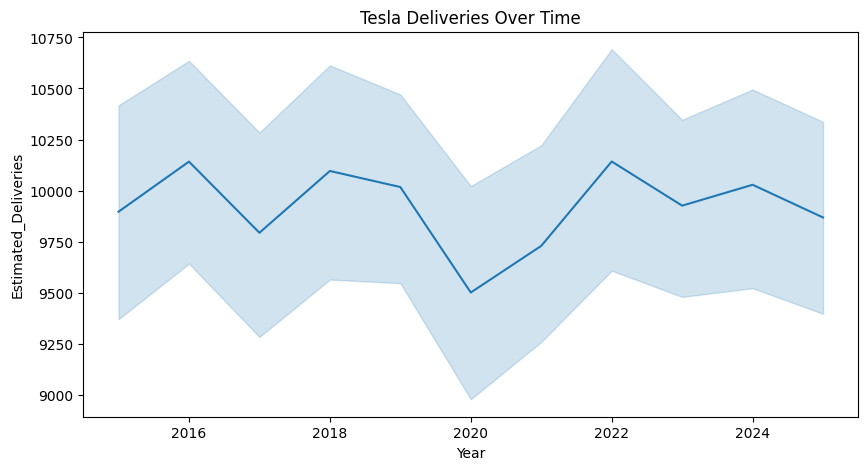

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Estimated_Deliveries"
)

plt.title("Tesla Deliveries Over Time")
plt.show()

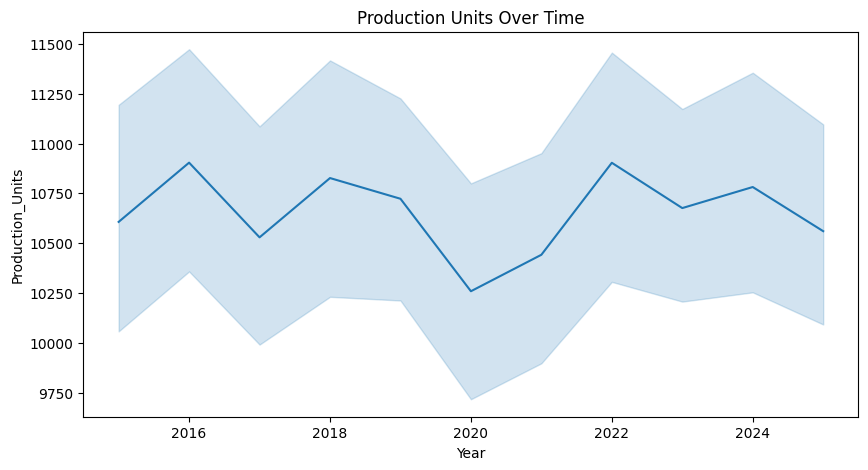

In [31]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Production_Units"
)

plt.title("Production Units Over Time")

plt.show()

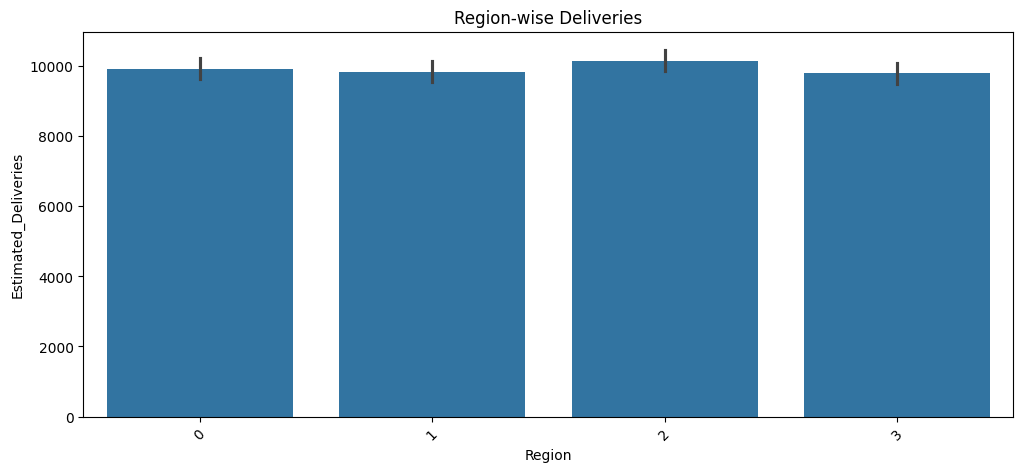

In [32]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.title("Region-wise Deliveries")

plt.show()

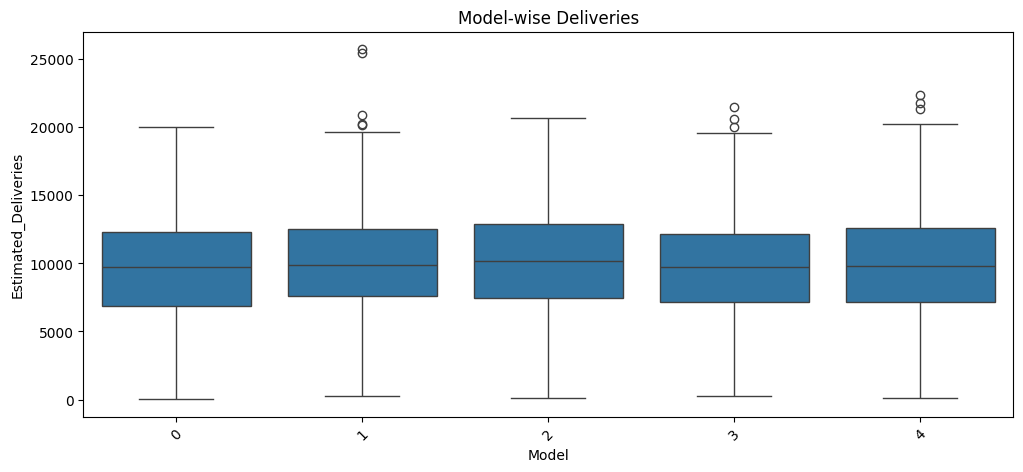

In [33]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.title("Model-wise Deliveries")

plt.show()

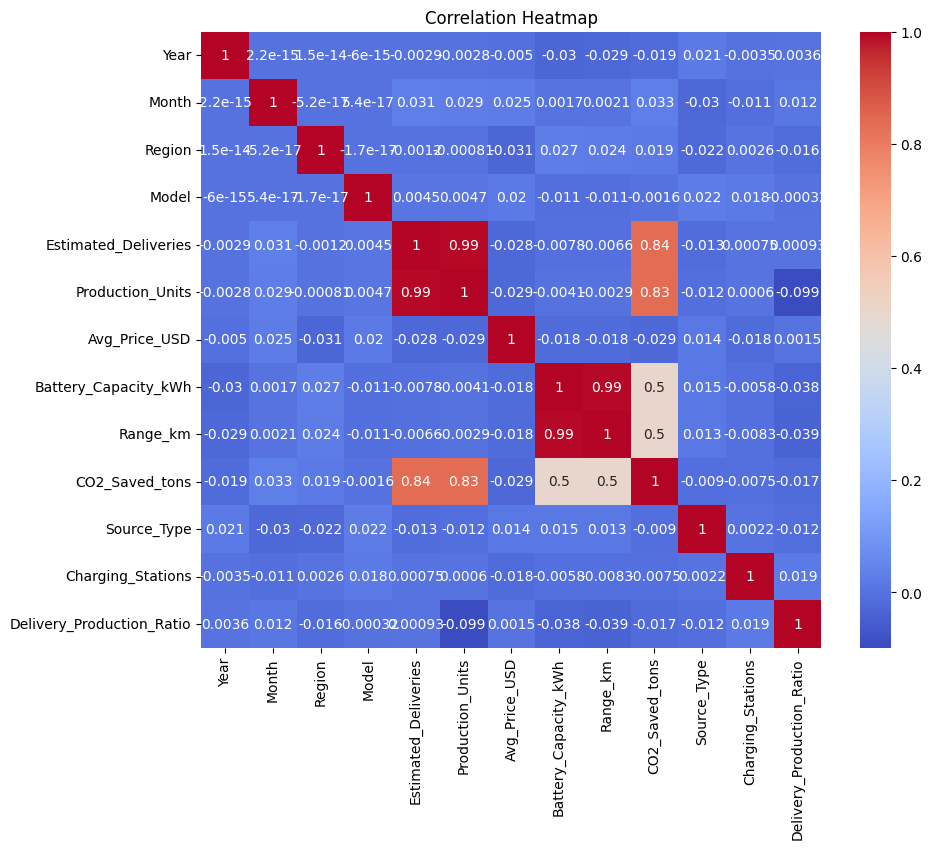

In [34]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# 4. Feature Engineering

In [35]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

df["Delivery_Production_Ratio"] = (
    df["Estimated_Deliveries"]
    /
    df["Production_Units"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Production_Ratio
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,0.984600
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,0.911864
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,0.915334
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,0.896594
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,0.914087


# 5. Data Preprocessing

In [36]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])

df["Model"] = le_model.fit_transform(df["Model"])

df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

In [37]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

y = df["Estimated_Deliveries"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Linear Regression Model

In [39]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

print("R2 Score:",
      r2_score(y_test, pred_lr))

print("MAE:",
      mean_absolute_error(y_test, pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_lr)))

R2 Score: 0.998423201888755
MAE: 108.76917173561014
RMSE: 153.31081819326295


# 7. Random Forest Regressor

In [40]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

print("R2 Score:",
      r2_score(y_test, pred_rf))

print("MAE:",
      mean_absolute_error(y_test, pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_rf)))

R2 Score: 0.9991543351316148
MAE: 67.05098484848484
RMSE: 112.27521628927299


In [41]:
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ],
    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ]
})

results

,Model,R2,MAE
0,Linear Regression,0.998423,108.769172
1,Random Forest,0.999154,67.050985


# 8. Hyperparameter Tuning

In [42]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10]

}

In [43]:
search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

search.fit(
    X_train,
    y_train
)

best_model = search.best_estimator_

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}


In [44]:
pred_best = best_model.predict(X_test)

print("Final Model Metrics")

print("R2 Score:",
      r2_score(y_test,pred_best))

print("MAE:",
      mean_absolute_error(y_test,pred_best))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_best)))

Final Model Metrics
R2 Score: 0.9991860012625792
MAE: 67.1068143862596
RMSE: 110.15307404046642


# 9. Feature Importance

In [45]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Production_Units,0.990561
11,Delivery_Production_Ratio,0.008666
8,CO2_Saved_tons,0.000255
5,Avg_Price_USD,0.000090
10,Charging_Stations,0.000078
7,Range_km,0.000078
1,Month,0.000072
0,Year,0.000068
3,Model,0.000044
2,Region,0.000043


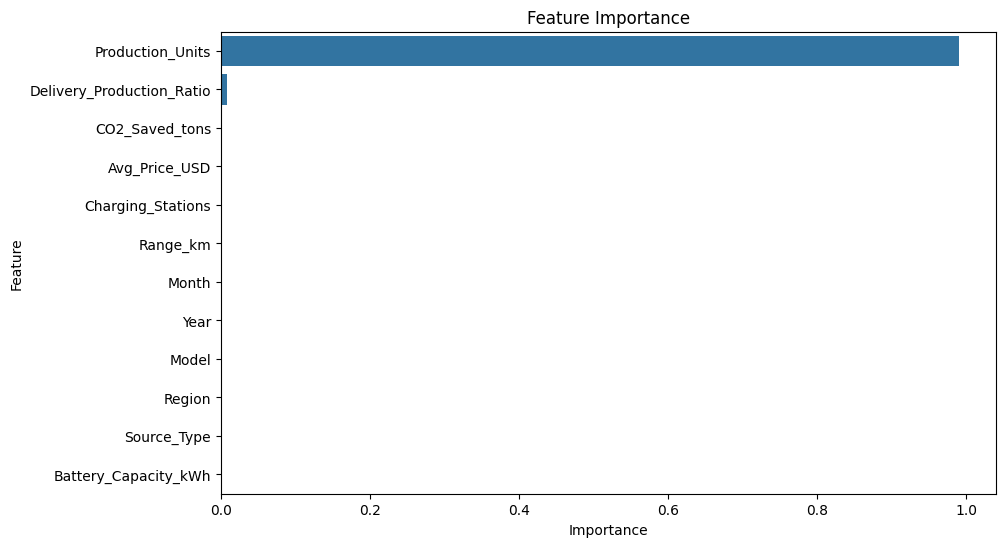

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# 10. Time Series Forecasting using ARIMA

In [47]:
ts = df.groupby("Date")[
    "Estimated_Deliveries"
].sum()

ts.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

In [48]:
model = ARIMA(
    ts,
    order=(5,1,0)
)

model_fit = model.fit()

In [49]:
forecast = model_fit.forecast(
    steps=12
)

forecast

2026-01-01    203819.655291
2026-02-01    202894.176206
2026-03-01    199011.662570
2026-04-01    198667.010481
2026-05-01    200971.493836
2026-06-01    201391.449841
2026-07-01    201412.663908
2026-08-01    201031.409116
2026-09-01    200601.086697
2026-10-01    200710.068210
2026-11-01    200864.721557
2026-12-01    200936.680131
Freq: MS, Name: predicted_mean, dtype: float64

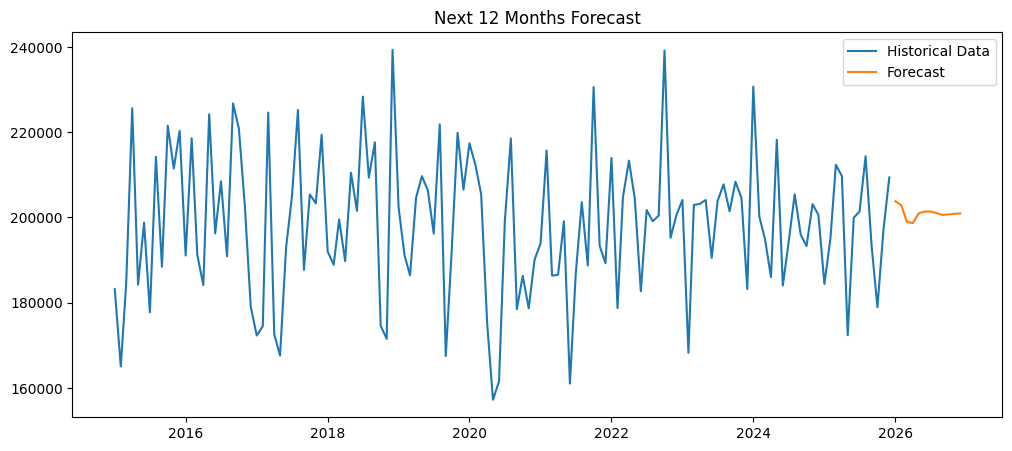

In [50]:
plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label="Historical Data"
)

plt.plot(
    forecast.index,
    forecast,
    label="Forecast"
)

plt.legend()

plt.title("Next 12 Months Forecast")

plt.show()